# Data and libraries' imports

In [1]:
import numpy as np, pandas as pd,matplotlib.pyplot as plt, seaborn as sns,openpyxl, pandas as pd
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [2]:
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_excel(r"..\data\real_estate_data.xlsx")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      1037 non-null   str    
 1   Location                   1037 non-null   str    
 2   Rooms                      856 non-null    float64
 3   Shower Rooms               853 non-null    float64
 4   Area                       1037 non-null   str    
 5   Type                       1037 non-null   str    
 6   Housing stock              860 non-null    str    
 7   Price                      1037 non-null   str    
 8   Floor                      635 non-null    str    
 9   Heating                    454 non-null    str    
 10  Has furniture              1037 non-null   bool   
 11  Has AC                     1037 non-null   bool   
 12  Has underfloor heating     1037 non-null   bool   
 13  Has double glazed windows  1037 non-null   bool   
 14  Des

In [5]:
df.head(5)

,Title,Location,Rooms,Shower Rooms,Area,Type,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,Destination,URL
0,"Apartament cu 2 camere, sect. Botanica","Bulevardul Dacia Chișinău, Chișinău",2.0,1.0,61 m²,Apartament,Secundar (Vechi),85.900 EUR,1 / 9,Centralizată,True,True,False,True,NaN,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru","Șoseaua Hîncești, Chișinău, Chișinău",1.0,1.0,51.5 m²,Apartament,Bloc Nou,72.100 EUR,6 / 9,Autonomă,True,False,False,False,NaN,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
2,"Casă cu 2 niveluri, sect. Ciocana","Strada Mihail Sadoveanu Chișinău, Chișinău",4.0,4.0,450 m²,Casă,Bloc Nou,580.000 EUR,2 / 2,Autonomă,True,True,True,True,NaN,https://immobiliare.md/listing/casa-cu-2-niveluri-sect-ciocana-lfj4c
3,"Teren pentru construcție, or. Stăuceni",Chișinău,NaN,NaN,1 ha,Teren,NaN,750.000 EUR,NaN,NaN,False,False,False,False,Intravilan / Construcție,https://immobiliare.md/listing/teren-pentru-constructie-or-stauceni-gzore
4,"Apartament cu 1 cameră, sect. Ciocana","Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1.0,1.0,46 m²,Apartament,Bloc Nou,104.900 EUR,14 / 17,Autonomă,True,True,False,True,NaN,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613


# Questions

What sector's is more stable? -   lowest gap between mean and median  (stability here means low price dispersion)  
Which feature adds the most value?  - highest correlation with price  
Is price linear with m^2 and is there a change with high total area? - analysing the gragh of area and price and analysing different regression models.   
How much does sector influence price compared to area?  - comparison in coefficients of sector and area in a model 


# Data cleaning

Gathering apartments only, also droping column "Type" because it is constant across the dataframe

In [6]:
df_aparts = df[df['Type'] == 'Apartament']
df_aparts.info()

<class 'pandas.DataFrame'>
Index: 568 entries, 0 to 1033
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      568 non-null    str    
 1   Location                   568 non-null    str    
 2   Rooms                      567 non-null    float64
 3   Shower Rooms               567 non-null    float64
 4   Area                       568 non-null    str    
 5   Type                       568 non-null    str    
 6   Housing stock              568 non-null    str    
 7   Price                      568 non-null    str    
 8   Floor                      559 non-null    str    
 9   Heating                    335 non-null    str    
 10  Has furniture              568 non-null    bool   
 11  Has AC                     568 non-null    bool   
 12  Has underfloor heating     568 non-null    bool   
 13  Has double glazed windows  568 non-null    bool   
 14  Destinati

## Removing irrelevant data

In [7]:
df_aparts[df_aparts['Type'] != 'Apartament'].count().sum()

np.int64(0)

Destination and Type are just irrelevant with all values being null or 'Apartament'.  
They must be dropped.

In [8]:
df_aparts = df_aparts.drop(['Destination','Type'], axis = 1)

In [9]:
df_aparts.duplicated().sum()

np.int64(0)

In [10]:
# No duplicates

## Handling missing values

In [11]:
df_aparts['Rooms'].isna().sum()

np.int64(1)

In [12]:
df_aparts[df_aparts['Rooms'].isna()]

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
228,"Apartament cu 1 cameră, sect. Botanica","Strada Independenței Chișinău, Chișinău",NaN,1.0,32 m²,Secundar (Vechi),57.500 EUR,7 / 7,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-6tip0


In [13]:
#It is a signle room apartment
df_aparts.loc[df_aparts['Rooms'].isna(),'Rooms'] = 1

In [14]:
df_aparts['Shower Rooms'].isna().sum()

np.int64(1)

In [15]:
df_aparts[df_aparts['Shower Rooms'].isna()]

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
869,"Apartament cu 1 cameră, sect. Râșcani","str. Circului, Chișinău, Chișinău",1.0,NaN,49 m²,Bloc Nou,121.500 EUR,3/4,NaN,True,False,True,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-rascani-au03z


The number of apartments without bathroom mention is 1. I will fill it with 1.

In [16]:
df_aparts.loc[df['Shower Rooms'].isna(),'Shower Rooms'] = 1

After inspecting, apartment 85 is most likely for rent. It needs to be deleted

In [17]:
df_aparts = df_aparts[df_aparts['URL'] != 'https://immobiliare.md/listing/rascani-2-camere-1776181444143849']

## Standardizing data formats and names

In [18]:
df_aparts['Area'] = df_aparts['Area'].str.split(r'\s').str[0]

In [19]:
df_aparts

,Title,Location,Rooms,Shower Rooms,Area,Housing stock,Price,Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica","Bulevardul Dacia Chișinău, Chișinău",2.0,1.0,61,Secundar (Vechi),85.900 EUR,1 / 9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru","Șoseaua Hîncești, Chișinău, Chișinău",1.0,1.0,51.5,Bloc Nou,72.100 EUR,6 / 9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana","Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1.0,1.0,46,Bloc Nou,104.900 EUR,14 / 17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru","Strada Pietrarilor Chișinău, Chișinău",3.0,2.0,104,Bloc Nou,299.000 EUR,6 / 17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani","Strada Ion Pelivan Chișinău, Chișinău",2.0,1.0,48,Secundar (Vechi),94.500 EUR,1 / 5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,"Apartament cu 2 camere, sect. Râșcani","str. Nadejda Russo, Chișinău, Chișinău",2.0,1.0,81,Bloc Nou,320.000 EUR,7 / 10,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-3txgv
1018,"Apartament cu 3 camere, sect. Centru","str. Alessandro Bernardazzi, Chișinău, Chișinău",3.0,1.0,87,Bloc Nou,248.000 EUR,2/2,NaN,True,False,False,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-pn9rh
1026,"Apartament cu 2 camere, sect. Râșcani","str. Calea Orheiului, Chișinău, Chișinău",2.0,1.0,80,Bloc Nou,132.230 EUR,1/16,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-rwkv7
1027,"Apartament cu 2 camere, sect. Râșcani","str. Calea Orheiului, Chișinău, Chișinău",2.0,1.0,78,Bloc Nou,129.380 EUR,1/16,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-1k44m


In [20]:
df_aparts['Price'] = df_aparts['Price'].str.split(r'\s').str[0]

In [21]:
df_aparts = df_aparts.rename({'Area': 'Area m²','Price': 'Price (thousands of €)'},axis = 1)
df_aparts.head(5)

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica","Bulevardul Dacia Chișinău, Chișinău",2.0,1.0,61,Secundar (Vechi),85.900,1 / 9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru","Șoseaua Hîncești, Chișinău, Chișinău",1.0,1.0,51.5,Bloc Nou,72.100,6 / 9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana","Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1.0,1.0,46,Bloc Nou,104.900,14 / 17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru","Strada Pietrarilor Chișinău, Chișinău",3.0,2.0,104,Bloc Nou,299.000,6 / 17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani","Strada Ion Pelivan Chișinău, Chișinău",2.0,1.0,48,Secundar (Vechi),94.500,1 / 5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


In [22]:
df_aparts = df_aparts.astype({
    'Rooms': int,
    'Shower Rooms': int,
    'Area m²': float,
    'Price (thousands of €)': float
})

In [23]:
total_floors = df_aparts['Floor'].str.split('/').str[1]
df_aparts.insert(8,'Total Floors',total_floors)
df_aparts['Floor'] = df_aparts['Floor'].str.split('/').str[0]

In [24]:
df_aparts.head()

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica","Bulevardul Dacia Chișinău, Chișinău",2,1,61.0,Secundar (Vechi),85.9,1,9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru","Șoseaua Hîncești, Chișinău, Chișinău",1,1,51.5,Bloc Nou,72.1,6,9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana","Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1,1,46.0,Bloc Nou,104.9,14,17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru","Strada Pietrarilor Chișinău, Chișinău",3,2,104.0,Bloc Nou,299.0,6,17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani","Strada Ion Pelivan Chișinău, Chișinău",2,1,48.0,Secundar (Vechi),94.5,1,5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


### Price and area plotting to see outliers

In [25]:
price = df_aparts['Price (thousands of €)']
area = df_aparts['Area m²']

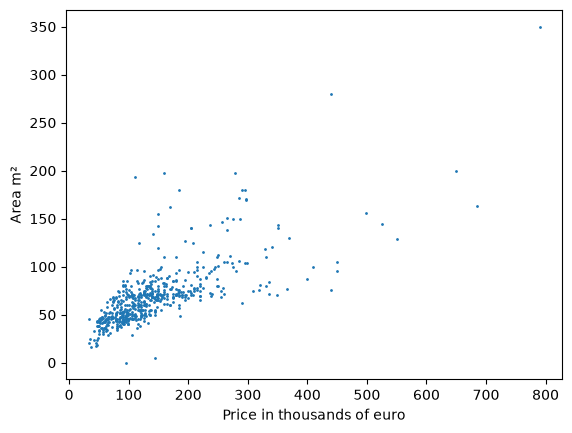

In [26]:
plt.scatter(price,area,1)
plt.xlabel("Price in thousands of euro")
plt.ylabel("Area m²")
plt.show()

Some outliers need to be inspected

In [27]:
df_aparts[df_aparts['Area m²'] > 190]

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
530,"Penthouse cu 3 camere, sect. Botanica","str. Burebista, Chișinău, Chișinău",3,3,280.0,Bloc Nou,440.0,15,16,Autonomă,True,True,True,True,https://immobiliare.md/listing/penthouse-cu-3-camere-sect-botanica-aawsv
531,"Apartament la sol cu 4 camere, sect. Centru","str. Alexei Sciusev, Chișinău, Chișinău",4,3,198.0,Secundar (Vechi),279.0,1,1,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-la-sol-cu-4-camere-sect-centru-zgdpn
645,"Penthouse cu 2 niveluri, sect. Botanica","str. Grenoble, Chișinău, Chișinău",4,3,350.0,Bloc Nou,790.0,NaN,NaN,Autonomă,True,True,True,True,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-cfno4
662,"Penthouse cu 2 niveluri, sect. Botanica","str. Decebal, Chișinău, Chișinău",3,2,200.0,Bloc Nou,650.0,9,10,Autonomă,True,True,True,True,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-48gud
957,"Casă cu 2 niveluri, loc. Hulboaca,com Grătiești","Hulboaca, com. Grătiești, Chișinău, Chișinău",4,3,198.0,Bloc Nou,159.0,2,2,Autonomă,True,False,False,False,https://immobiliare.md/listing/casa-cu-2-niveluri-loc-hulboacacom-gratiesti-ekrk4
996,"Penthouse cu 2 camere, or. Tiraspol","Tiraspol, str. 1 Mai, Chișinău, Chișinău",2,2,193.0,Bloc Nou,110.0,11,11,Autonomă,True,True,True,True,https://immobiliare.md/listing/penthouse-cu-2-camere-or-tiraspol-dmd8i


There is a house. It should be removed because we analyse apartments only

In [28]:
df_aparts = df_aparts.drop(1003)

It would be useful to see if there are other houses in this dataframe

In [29]:
df_aparts[df_aparts['Title'].str.contains("Casă")]

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
409,"Casă, com. Băcioi","str. Sfânta Treime, Chișinău, Chișinău",4,2,138.0,Bloc Nou,264.9,NaN,NaN,Autonomă,True,False,True,False,https://immobiliare.md/listing/casa-com-bacioi-7lufp
670,"Casă cu 2 niveluri, com. Dumbrava","Dumbrava, str. Mugurel, Chișinău, Chișinău",4,2,180.0,Bloc Nou,185.0,NaN,NaN,NaN,True,False,False,False,https://immobiliare.md/listing/casa-cu-2-niveluri-com-dumbrava-2nfn4
957,"Casă cu 2 niveluri, loc. Hulboaca,com Grătiești","Hulboaca, com. Grătiești, Chișinău, Chișinău",4,3,198.0,Bloc Nou,159.0,2,2,Autonomă,True,False,False,False,https://immobiliare.md/listing/casa-cu-2-niveluri-loc-hulboacacom-gratiesti-ekrk4


They all must be deleted

In [30]:
df_aparts = df_aparts[~df_aparts['Title'].str.contains("Casă")]
df_aparts.shape

(564, 15)

### 

In [31]:
df_aparts.head(5)

,Title,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica","Bulevardul Dacia Chișinău, Chișinău",2,1,61.0,Secundar (Vechi),85.9,1,9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru","Șoseaua Hîncești, Chișinău, Chișinău",1,1,51.5,Bloc Nou,72.1,6,9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana","Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1,1,46.0,Bloc Nou,104.9,14,17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru","Strada Pietrarilor Chișinău, Chișinău",3,2,104.0,Bloc Nou,299.0,6,17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani","Strada Ion Pelivan Chișinău, Chișinău",2,1,48.0,Secundar (Vechi),94.5,1,5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


Created a dictionary to group data in 5 sectors - Centru, Botanica, Ciocana, Rascani, Buiucani

In [32]:
df_sectors = {
    'centru': 'Centru',
    'ceucari': 'Centru',
    'frumușica': 'Centru',
    'hrusca': 'Centru',
    'melestiu': 'Centru',
    'schinoasa': 'Centru',
    'telecentru': 'Centru',
    'valea dicescu': 'Centru',

    'botanica': 'Botanica',
    'frumușica': 'Botanica',
    'galata': 'Botanica',
    'mălina mare': 'Botanica',
    'muncești': 'Botanica',

    'ciocana': 'Ciocana',
    'otovasca': 'Ciocana',

    'rîșcani': 'Râșcani',
    'râșcani': 'Râșcani',
    'petricani': 'Râșcani',
    'poșta veche': 'Râșcani',
    'visterniceni': 'Râșcani',

    'buiucani': 'Buiucani',
    'sculeni': 'Buiucani'

}

In [33]:
df_aparts['Sector'] = df_aparts['Title'].str.lower().str.split(r'.').str[1].str[1:].map(df_sectors)

All apartments outside of Chisinau are outside of the scope of this analysis. They will be removed.

In [34]:
df_aparts = df_aparts[~df_aparts['Sector'].isna()]

In [35]:
df_aparts.info()

<class 'pandas.DataFrame'>
Index: 444 entries, 0 to 1033
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      444 non-null    str    
 1   Location                   444 non-null    str    
 2   Rooms                      444 non-null    int64  
 3   Shower Rooms               444 non-null    int64  
 4   Area m²                    444 non-null    float64
 5   Housing stock              444 non-null    str    
 6   Price (thousands of €)     444 non-null    float64
 7   Floor                      441 non-null    object 
 8   Total Floors               441 non-null    object 
 9   Heating                    264 non-null    str    
 10  Has furniture              444 non-null    bool   
 11  Has AC                     444 non-null    bool   
 12  Has underfloor heating     444 non-null    bool   
 13  Has double glazed windows  444 non-null    bool   
 14  URL      

In [36]:
col = df_aparts.pop('Sector')
df_aparts.insert(1,'Sector',col)

In [37]:
df_aparts.head()

,Title,Sector,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica",Botanica,"Bulevardul Dacia Chișinău, Chișinău",2,1,61.0,Secundar (Vechi),85.9,1,9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru",Centru,"Șoseaua Hîncești, Chișinău, Chișinău",1,1,51.5,Bloc Nou,72.1,6,9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana",Ciocana,"Bulevardul Mircea cel Bătrân Chișinău, Chișinău",1,1,46.0,Bloc Nou,104.9,14,17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru",Centru,"Strada Pietrarilor Chișinău, Chișinău",3,2,104.0,Bloc Nou,299.0,6,17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani",Buiucani,"Strada Ion Pelivan Chișinău, Chișinău",2,1,48.0,Secundar (Vechi),94.5,1,5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


In [38]:
df_aparts['Housing stock'].value_counts()

Housing stock
Bloc Nou            326
Secundar (Vechi)    115
În construcție        3
Name: count, dtype: int64

In [39]:
df_aparts[df_aparts['Housing stock'] == 'În construcție']

,Title,Sector,Location,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
43,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Bulevardul Dacia Chișinău, Chișinău",1,1,38.40,În construcție,48.75,15,20,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-v16ot
44,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Bulevardul Dacia Chișinău, Chișinău",1,1,38.40,În construcție,48.75,17,20,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-bqz10
77,"Apartament cu 1 cameră, sect. Botanica",Botanica,"Strada Grădina Botanică Chișinău, Chișinău",1,1,52.25,În construcție,84.90,11,16,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-botanica-gafco


Will merge "In Constructie" to  "Bloc nou" because there are only 3 records

In [40]:
df_aparts["Housing stock"] = df_aparts["Housing stock"].replace(
    "În construcție", "Bloc Nou"
)

At this point location is useless. It should be droped.

In [41]:
df_aparts = df_aparts.drop(['Location'], axis = 1)
df_aparts.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,61.0,Secundar (Vechi),85.9,1,9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru",Centru,1,1,51.5,Bloc Nou,72.1,6,9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana",Ciocana,1,1,46.0,Bloc Nou,104.9,14,17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru",Centru,3,2,104.0,Bloc Nou,299.0,6,17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani",Buiucani,2,1,48.0,Secundar (Vechi),94.5,1,5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


## Feature engineering
Note. Here i noticed scraper's bug. After fixing floor extraction, misleading information will not be present in floor column (e.g. 8/1)

In [42]:
df_aparts[df_aparts['Floor'].str.split("/").str[1] == '1']

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL


In [43]:
df_aparts[df_aparts['Floor'].isna()]

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
175,"Apartament cu 3 camere, sect. Telecentru",Centru,3,2,74.0,Bloc Nou,95.0,NaN,NaN,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-3-camere-sect-telecentru-vj4rn
645,"Penthouse cu 2 niveluri, sect. Botanica",Botanica,4,3,350.0,Bloc Nou,790.0,NaN,NaN,Autonomă,True,True,True,True,https://immobiliare.md/listing/penthouse-cu-2-niveluri-sect-botanica-cfno4
948,"Apartament cu 2 camere, sect. Ciocana",Ciocana,2,1,57.0,Bloc Nou,107.0,NaN,NaN,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-ciocana-wcux2


 7 rows with NaN values in floors. They won't be droped because they do not represent core features like area or price

In [44]:
df_aparts['Floor'] = df_aparts['Floor'].astype('Int64')
df_aparts['Total Floors'] = df_aparts['Total Floors'].astype('Int64')

In [45]:
df_aparts.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,61.0,Secundar (Vechi),85.9,1,9,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru",Centru,1,1,51.5,Bloc Nou,72.1,6,9,Autonomă,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana",Ciocana,1,1,46.0,Bloc Nou,104.9,14,17,Autonomă,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru",Centru,3,2,104.0,Bloc Nou,299.0,6,17,Autonomă,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani",Buiucani,2,1,48.0,Secundar (Vechi),94.5,1,5,Centralizată,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


In [46]:
df_aparts = df_aparts.rename({'Heating': 'Autonom Heating'},axis = 1)

In [47]:
df_aparts['Autonom Heating'].value_counts(dropna=False)

Autonom Heating
Autonomă        204
NaN             180
Centralizată     60
Name: count, dtype: int64

### Encoding and filling missing values in heating.

In [48]:
heating_map = {
    'Autonomă' : 'Autonomă',
    'Autonomă (gaz)': 'Autonomă',
    'Centralizată': 'Centralizată'
}

In [49]:
df_aparts['Autonom Heating'] = df_aparts['Autonom Heating'].map(heating_map)

In [50]:
df_aparts[df_aparts['Autonom Heating'] == 'Apartament cu 1 cameră, sect. Botanica'] 

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL


In [51]:
df_aparts['Autonom Heating'] = (df_aparts['Autonom Heating'] == 'Autonomă')

In [52]:
df_aparts.head(5)

,Title,Sector,Rooms,Shower Rooms,Area m²,Housing stock,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL
0,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,61.0,Secundar (Vechi),85.9,1,9,False,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj
1,"Apartament cu 1 cameră, sect. Telecentru",Centru,1,1,51.5,Bloc Nou,72.1,6,9,True,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj
4,"Apartament cu 1 cameră, sect. Ciocana",Ciocana,1,1,46.0,Bloc Nou,104.9,14,17,True,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613
5,"Apartament cu 3 camere, sect. Centru",Centru,3,2,104.0,Bloc Nou,299.0,6,17,True,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm
11,"Apartament cu 2 camere, sect. Buiucani",Buiucani,2,1,48.0,Secundar (Vechi),94.5,1,5,False,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf


### Encoding values in housing stock.

In [53]:
df_aparts = pd.get_dummies(df_aparts,columns = ["Housing stock"], drop_first = True)

In [54]:
df_aparts

,Title,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL,Housing stock_Secundar (Vechi)
0,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,61.0,85.90,1,9,False,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-d41nj,True
1,"Apartament cu 1 cameră, sect. Telecentru",Centru,1,1,51.5,72.10,6,9,True,True,False,False,False,https://immobiliare.md/listing/apartament-cu-1-camera-sect-telecentru-pa6tj,False
4,"Apartament cu 1 cameră, sect. Ciocana",Ciocana,1,1,46.0,104.90,14,17,True,True,True,False,True,https://immobiliare.md/listing/apartament-cu-1-camera-sect-ciocana-er613,False
5,"Apartament cu 3 camere, sect. Centru",Centru,3,2,104.0,299.00,6,17,True,True,True,True,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-dlafm,False
11,"Apartament cu 2 camere, sect. Buiucani",Buiucani,2,1,48.0,94.50,1,5,False,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-buiucani-dxbmf,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,"Apartament cu 2 camere, sect. Râșcani",Râșcani,2,1,81.0,320.00,7,10,True,True,True,True,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-3txgv,False
1018,"Apartament cu 3 camere, sect. Centru",Centru,3,1,87.0,248.00,2,2,False,True,False,False,True,https://immobiliare.md/listing/apartament-cu-3-camere-sect-centru-pn9rh,False
1026,"Apartament cu 2 camere, sect. Râșcani",Râșcani,2,1,80.0,132.23,1,16,True,True,False,False,False,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-rwkv7,False
1027,"Apartament cu 2 camere, sect. Râșcani",Râșcani,2,1,78.0,129.38,1,16,True,True,False,False,False,https://immobiliare.md/listing/apartament-cu-2-camere-sect-rascani-1k44m,False


### Creating price per m^2 column

In [55]:
df_aparts['Price per m² (thousands of €)'] = round(df_aparts['Price (thousands of €)']/df_aparts['Area m²'],2)

In [56]:
col = df_aparts.pop('Price per m² (thousands of €)')
df_aparts.insert(6,'Price per m² (thousands of €)',col)

In [57]:
df_aparts[df_aparts['Area m²'] <=0 ]

,Title,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Price per m² (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,URL,Housing stock_Secundar (Vechi)
525,"Apartament cu 2 camere, sect. Botanica",Botanica,2,1,0.0,95.5,inf,3,5,False,True,True,False,True,https://immobiliare.md/listing/apartament-cu-2-camere-sect-botanica-7g7k7,True


This observation represents a detached house while the analysis focuses exclusively on apartments. Keeping it would create bias.

In [58]:
df_aparts = df_aparts[df_aparts['Area m²'] >= 15 ]

# Analysing the data

In [59]:
df_analysis = df_aparts.copy()

In [60]:
median_sector = df_analysis.groupby('Sector')['Price (thousands of €)'].median().sort_values(ascending = False)
median_sector

Sector
Buiucani    145.00
Centru      137.75
Râșcani     125.80
Ciocana     119.40
Botanica    112.20
Name: Price (thousands of €), dtype: float64

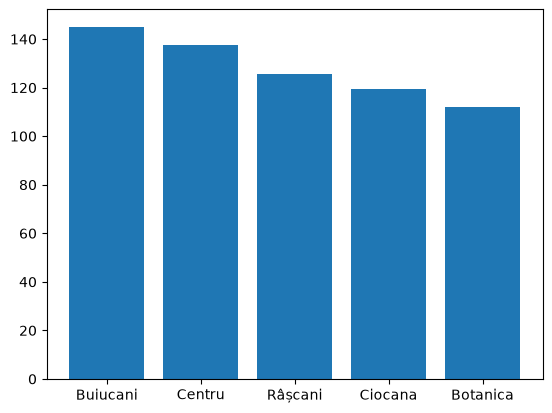

In [61]:
plt.bar(median_sector.index,median_sector.values)
plt.show()

In [62]:
mean_sector = df_analysis.groupby('Sector')['Price (thousands of €)'].mean().sort_values(ascending = False)
mean_sector

Sector
Centru      174.885382
Buiucani    160.544694
Râșcani     153.007130
Botanica    125.480705
Ciocana     124.139700
Name: Price (thousands of €), dtype: float64

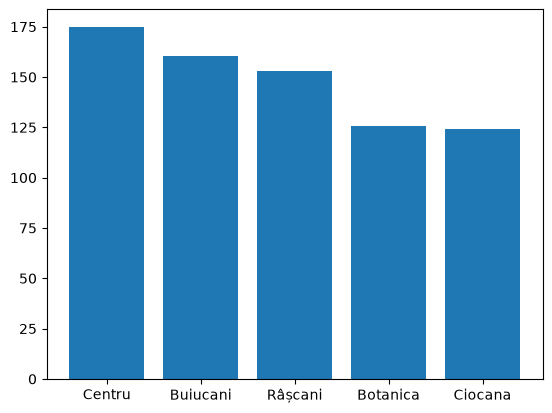

In [63]:
plt.bar(mean_sector.index,mean_sector.values)
plt.show()

In [64]:
comparison = df_analysis.groupby('Sector')['Price (thousands of €)'].agg(['median','mean'])
comparison['gap'] = comparison['mean'] - comparison['median']
comparison.sort_values('gap',ascending = False)

,median,mean,gap
Sector,,,
Centru,137.75,174.885382,37.135382
Râșcani,125.80,153.007130,27.207130
Buiucani,145.00,160.544694,15.544694
Botanica,112.20,125.480705,13.280705
Ciocana,119.40,124.139700,4.739700


From above illustration: Buiucani has the highest median price (147k), suggesting consistently high quality stock, while Centru shows the largest mean-median gap (36.5k), indicating a polarized market with both affordable Soviet-era apartments and premium properties coexisting in the same sector.

## Question 1 ANSWER:
Ciocana exhibits the smallest difference between mean and median apartment prices, indicating lower price dispersion compared with other sectors.

In [65]:
price = df_analysis['Price (thousands of €)']
sector = df_analysis['Sector']
area = df_analysis['Area m²']

<Axes: xlabel='Area m²', ylabel='Price (thousands of €)'>

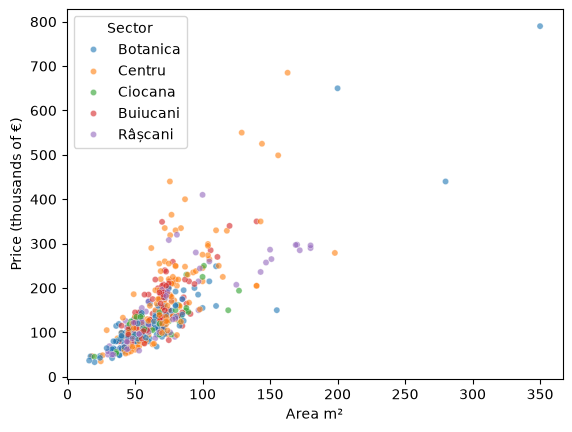

In [66]:
sns.scatterplot(df_aparts,x = area,y = price,hue = sector,s = 20,alpha = 0.6)


<function matplotlib.pyplot.show(close=None, block=None)>

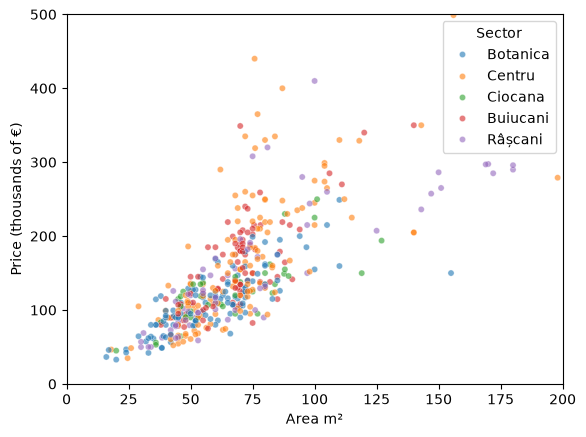

In [67]:
sns.scatterplot(df_aparts,x = area,y = price,hue = sector,s = 20,alpha = 0.6)
plt.xlim(0,200)
plt.ylim(0,500)
plt.show

In [68]:
price_per_m_squared =  df_analysis['Price per m² (thousands of €)']

<Axes: xlabel='Sector', ylabel='Price per m² (thousands of €)'>

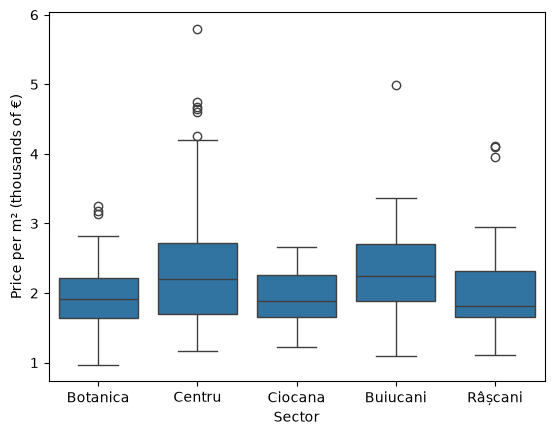

In [69]:
sns.boxplot(data = df_analysis,x = sector, y = price_per_m_squared)

In [70]:
corr = df_analysis.corr(numeric_only = True)

<Axes: >

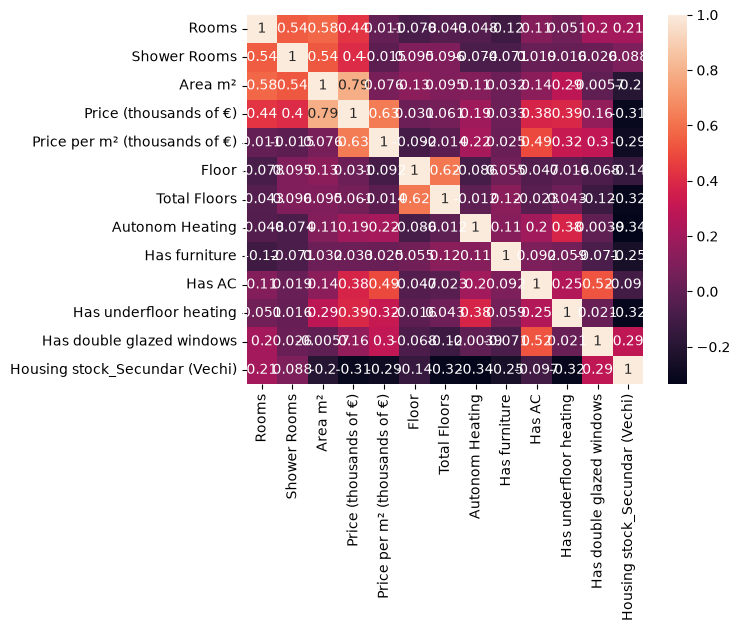

In [71]:
sns.heatmap(corr,annot = True)

## Question 2 ANSWER:
The heatmap above shows that area is dominant (!) in price determination.  
Plus, among 'has...' features, underfloor heating influences the most.   
But let's try to answer the question - how important is sector compared to area?   
For this, a copy of df_aparts will be created. Outliers will be deleted with use of IQR

# Creating the model

In [72]:
df_model = df_aparts.copy()

In [73]:
df_model['Sector'] = LabelEncoder().fit_transform(df_model['Sector'])

I will remove outliers with IQR for a better Linear Regression model.

In [74]:
Q1 = df_model['Price (thousands of €)'].quantile(0.25)
Q3 = df_model['Price (thousands of €)'].quantile(0.75)
IQR = Q3 - Q1

In [75]:
df_model = df_model[(df_model['Price (thousands of €)'] >= Q1 - 1.5*IQR) & 
                    (df_model['Price (thousands of €)'] <= Q3 + 1.5*IQR)]

In [76]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 420 entries, 0 to 1033
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Title                           420 non-null    str    
 1   Sector                          420 non-null    int64  
 2   Rooms                           420 non-null    int64  
 3   Shower Rooms                    420 non-null    int64  
 4   Area m²                         420 non-null    float64
 5   Price (thousands of €)          420 non-null    float64
 6   Price per m² (thousands of €)   420 non-null    float64
 7   Floor                           418 non-null    Int64  
 8   Total Floors                    418 non-null    Int64  
 9   Autonom Heating                 420 non-null    bool   
 10  Has furniture                   420 non-null    bool   
 11  Has AC                          420 non-null    bool   
 12  Has underfloor heating          420 non-null    boo

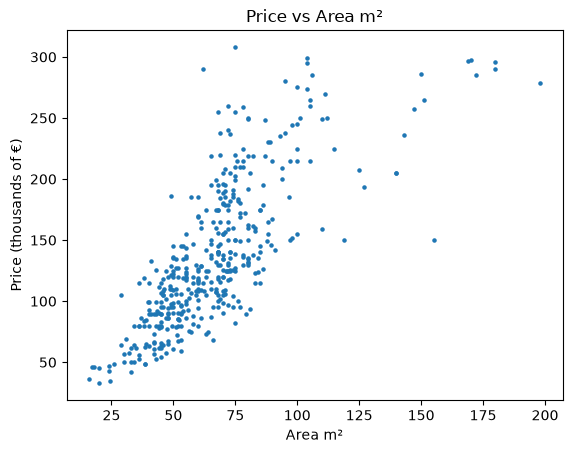

In [77]:
price = df_model['Price (thousands of €)']
area = df_model['Area m²']
plt.scatter(area,price,5)
plt.title('Price vs Area m²')
plt.xlabel('Area m²')
plt.ylabel('Price (thousands of €)')
plt.show()

 The above scatter plot shows the kind of dependency between price and area. It doesn't look linear. Two regressions - linear and logarithmic will be built to see which type it is

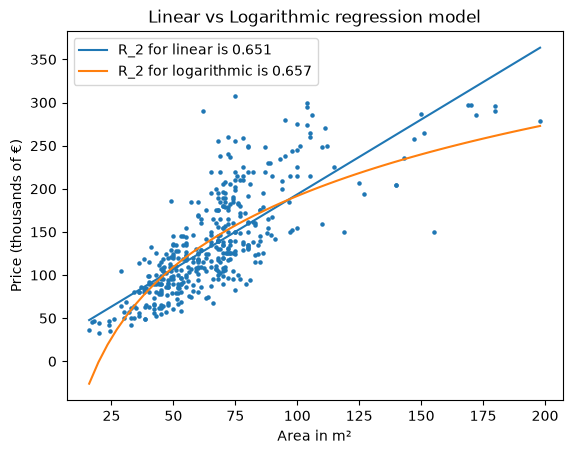

In [78]:
#Linear
X = df_model['Area m²'].values.reshape(-1,1)
Y = df_model['Price (thousands of €)'].values
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

linear_model = LinearRegression().fit(X_train,y_train)
r2_linear = r2_score(y_test,linear_model.predict(X_test))
# Logarithmic
log_model = LinearRegression().fit(np.log(X_train),y_train)
r2_log = r2_score(y_test,log_model.predict(np.log(X_test)))

x_range = np.linspace(X.min(),X.max(),50).reshape(-1,1)
plt.scatter(X,Y,5)
plt.plot(x_range,linear_model.predict(x_range), label = f'R_2 for linear is {r2_linear:.3f}')

plt.plot(x_range, log_model.predict(np.log(x_range)), label = f'R_2 for logarithmic is {r2_log:.3f}')

plt.title('Linear vs Logarithmic regression model')
plt.xlabel('Area in m²')
plt.ylabel('Price (thousands of €)')
plt.legend()
plt.show()

The R2 values for linear (0.651) and logarithmic (0.657) models are nearly identical, suggesting the area–price relationship is linear and does not change meaningfully with apartment size. Let's verify this by splitting apartments by size segment and comparing median price per m².

In [79]:
# Check average price/m² by size segment
df_model['Size segment'] = pd.cut(df_model['Area m²'], 
                                      bins=[0, 50, 80, 120, 300],
                                      labels=['Small', 'Medium', 'Large', 'Extra large'])

df_model.groupby('Size segment')['Price per m² (thousands of €)'].median()

Size segment
Small          2.00
Medium         2.00
Large          2.08
Extra large    1.65
Name: Price per m² (thousands of €), dtype: float64

In [80]:
df_model['Size segment'].value_counts()

Size segment
Medium         230
Small          116
Large           59
Extra large     15
Name: count, dtype: int64

## Question 3 ANSWER:
So it is (!)linear for apartments below 120m^2 with median price for m^2 ranging from 2000 - 2080 euros.  
But with extra large apartments there is a discount with 1650 euros being median price for m^2.  
It is good to notice there are only 15 extra large apartments so the drop might not be significant.  
More data is needed for future analysis

In [81]:
df_model = df_model.drop(['Size segment', 'Title', 'URL', 'Price per m² (thousands of €)'], axis = 1)

In [82]:
df_model.isna().sum()

Sector                            0
Rooms                             0
Shower Rooms                      0
Area m²                           0
Price (thousands of €)            0
Floor                             2
Total Floors                      2
Autonom Heating                   0
Has furniture                     0
Has AC                            0
Has underfloor heating            0
Has double glazed windows         0
Housing stock_Secundar (Vechi)    0
dtype: int64

Will drop those values with NaN values.

In [83]:
df_model = df_model.dropna(subset = 'Floor')
df_model = df_model.dropna(subset = 'Total Floors')

In [84]:
df_model.isna().sum()

Sector                            0
Rooms                             0
Shower Rooms                      0
Area m²                           0
Price (thousands of €)            0
Floor                             0
Total Floors                      0
Autonom Heating                   0
Has furniture                     0
Has AC                            0
Has underfloor heating            0
Has double glazed windows         0
Housing stock_Secundar (Vechi)    0
dtype: int64

In [85]:
df_model

,Sector,Rooms,Shower Rooms,Area m²,Price (thousands of €),Floor,Total Floors,Autonom Heating,Has furniture,Has AC,Has underfloor heating,Has double glazed windows,Housing stock_Secundar (Vechi)
0,0,2,1,61.0,85.90,1,9,False,True,True,False,True,True
1,2,1,1,51.5,72.10,6,9,True,True,False,False,False,False
4,3,1,1,46.0,104.90,14,17,True,True,True,False,True,False
5,2,3,2,104.0,299.00,6,17,True,True,True,True,True,False
11,1,2,1,48.0,94.50,1,5,False,True,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,0,3,2,105.0,215.00,9,12,True,True,True,True,True,False
1018,2,3,1,87.0,248.00,2,2,False,True,False,False,True,False
1026,4,2,1,80.0,132.23,1,16,True,True,False,False,False,False
1027,4,2,1,78.0,129.38,1,16,True,True,False,False,False,False


In [86]:
df_model['Shower Rooms'].dtype

dtype('int64')

In [87]:
scaler = StandardScaler()
X = df_model.drop(['Price (thousands of €)','Rooms','Shower Rooms'],axis = 1)
y = df_model['Price (thousands of €)']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

sector_mean = y_train.groupby(X_train['Sector']).mean()
X_train['Sector'] = X_train['Sector'].map(sector_mean)
X_test['Sector'] = X_test['Sector'].map(sector_mean)

overall_mean = y_train.mean()
X_test['Sector'] = X_test['Sector'].fillna(overall_mean)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression().fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2, mae

(0.7356006634969402, 22.81308088986212)

In [88]:
coefficients = pd.Series(model.coef_, index=X_train.columns)
coefficients.sort_values(ascending=False)

Area m²                           40.629186
Has double glazed windows         11.796560
Has AC                            10.591336
Sector                             6.899799
Has underfloor heating             5.604764
Total Floors                       5.510052
Autonom Heating                    0.088714
Has furniture                     -1.524335
Floor                             -5.175612
Housing stock_Secundar (Vechi)   -13.856094
dtype: float64

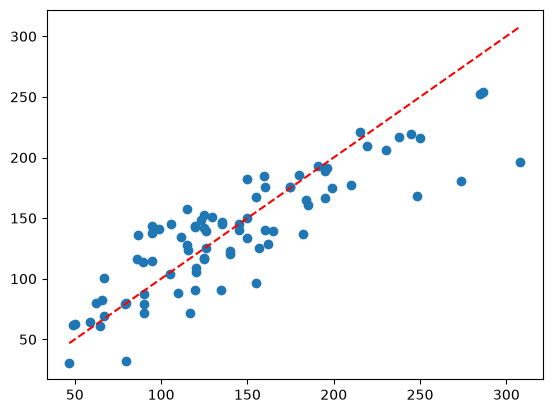

In [89]:
plt.scatter(y_test,model.predict(X_test_scaled))
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')

In [90]:
coefficients['Area m²']/coefficients['Sector']

np.float64(5.888459123007754)

## Question 4 ANSWER:
Area is 5.9x more influential than sector(!) in determining property price, according to coefficients.

## Experimenting with RandomForestRegressor

In [91]:
X_rf = df_model.drop(['Price (thousands of €)',],axis = 1)
y_rf = df_model['Price (thousands of €)']
X_train_rf,X_test_rf, y_train_rf, y_test_rf = train_test_split (X_rf, y_rf, test_size = 0.2, random_state = 42)

sector_mean_rf = y_train_rf.groupby(X_train_rf['Sector']).mean()
X_train_rf['Sector'] = X_train_rf['Sector'].map(sector_mean_rf)
X_test_rf['Sector'] = X_test_rf['Sector'].map(sector_mean_rf)

overall_mean_rf = y_train.mean()
X_test_rf['Sector'] = X_test_rf['Sector'].fillna(overall_mean_rf)

In [92]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train_rf,y_train_rf)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [93]:
y_pred_rf = rf.predict(X_test_rf)
r2_rf = r2_score(y_test_rf,y_pred_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
r2_rf, mae_rf

(0.7783658677147839, 20.57717253968254)

In [94]:
cross_val_score_lr = cross_val_score(model,X_train_scaled,y_train,cv=5,scoring='r2').mean()
cross_val_score_rf = cross_val_score(rf,X_train_rf,y_train_rf,cv=5,scoring ='r2').mean()

In [95]:
df_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'RandomForestRegressor'],
    'Average R2': [cross_val_score_lr, cross_val_score_rf],
    'Mean absolute error': [mae, mae_rf],
})
df_comparison

,Model,Average R2,Mean absolute error
0,Linear Regression,0.747927,22.813081
1,RandomForestRegressor,0.756742,20.577173


We can see what RandomForestRegression has a higher average R^2 and lower mean absolute value.
It is so because price is not totally dependent by the area, even if it is the most dominating feature.

In [96]:
df_feature_importance = pd.DataFrame(
    {
        'Feature': X_train_rf.columns,
        'Importance': rf.feature_importances_
    }
)
df_feature_importance

,Feature,Importance
0,Sector,0.036793
1,Rooms,0.007938
2,Shower Rooms,0.011511
3,Area m²,0.708657
4,Floor,0.035756
5,Total Floors,0.036521
6,Autonom Heating,0.013577
7,Has furniture,0.000659
8,Has AC,0.081991
9,Has underfloor heating,0.024447


<BarContainer object of 12 artists>

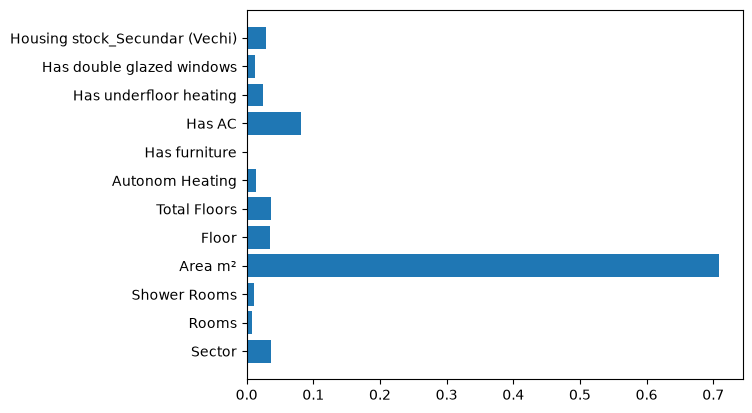

In [97]:
plt.barh(df_feature_importance['Feature'],df_feature_importance['Importance'])

We can see what area's dominance in comparison with other features.